# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3.2  Продвинутая генерация признаков


Перенесу сюда самые важные функции из базового ноута:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import category_encoders as ce
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

matches_df_train = pd.read_csv('/kaggle/input/competitions/dota-2-hse-ml-1-course-competition-2026/matches_df_train.csv')
matches_df_test = pd.read_csv('/kaggle/input/competitions/dota-2-hse-ml-1-course-competition-2026/matches_df_test.csv')
target = "radiant_win"

mathes_df_res_train = matches_df_train[target]
matches_df_train = matches_df_train.drop(['duration', target], axis = 1)
encoder = ce.OneHotEncoder(cols=['region'], use_cat_names=True)
matches_df_train_enc = encoder.fit_transform(matches_df_train)
matches_df_test_enc = encoder.transform(matches_df_test)
matches_df_train_enc[target] = mathes_df_res_train.values
matches_df_train_enc = matches_df_train_enc.drop('region_SE Asia', axis = 1)
matches_df_test_enc = matches_df_test_enc.drop('region_SE Asia', axis = 1)



matches_df_train_enc['date'] = pd.to_datetime(matches_df_train_enc['date'])
matches_df_test_enc['date'] = pd.to_datetime(matches_df_test_enc['date'])
matches_df_train_enc['weekday'] = matches_df_train_enc['date'].dt.weekday
matches_df_test_enc['weekday'] = matches_df_test_enc['date'].dt.weekday
mathes_df_res_train = matches_df_train_enc[target]
matches_df_train_enc = matches_df_train_enc.drop(target, axis = 1)
encoder2 = ce.OneHotEncoder(cols=['weekday'], use_cat_names=True)
matches_df_train_enc1 = encoder2.fit_transform(matches_df_train_enc)
matches_df_test_enc1 = encoder2.transform(matches_df_test_enc)
matches_df_train_enc1[target] = mathes_df_res_train.values
matches_df_train_enc1 = matches_df_train_enc1.drop(['weekday_0.0'], axis = 1)
matches_df_test_enc1 = matches_df_test_enc1.drop(['weekday_0.0'], axis = 1)

matches_df_train_enc1 = matches_df_train_enc1.sort_values('date')


matches_df_train_enc2 = matches_df_train_enc1.copy()
matches_df_test_enc2 = matches_df_test_enc1.copy()
matches_df_train_enc2['avg_mmr'] = np.sqrt(matches_df_train_enc1['avg_mmr'])
matches_df_test_enc2['avg_mmr'] = np.sqrt(matches_df_test_enc1['avg_mmr'])
matches_df_train_enc2['mmr_missing'] = matches_df_train_enc2['avg_mmr'].isna().astype(int)
matches_df_train_enc2['avg_mmr'] = matches_df_train_enc2['avg_mmr'].fillna(0)
matches_df_test_enc2['mmr_missing'] = matches_df_test_enc2['avg_mmr'].isna().astype(int)
matches_df_test_enc2['avg_mmr'] = matches_df_test_enc2['avg_mmr'].fillna(0)
matches_df_train_enc1['mmr_missing'] = matches_df_train_enc1['avg_mmr'].isna().astype(int)
matches_df_train_enc1['avg_mmr'] = matches_df_train_enc1['avg_mmr'].fillna(0)
matches_df_test_enc1['mmr_missing'] = matches_df_test_enc1['avg_mmr'].isna().astype(int)
matches_df_test_enc1['avg_mmr'] = matches_df_test_enc1['avg_mmr'].fillna(0)




In [2]:
player_df = pd.read_csv('/kaggle/input/competitions/dota-2-hse-ml-1-course-competition-2026/player_df.csv')
heroes_df = pd.read_csv('/kaggle/input/competitions/dota-2-hse-ml-1-course-competition-2026/Constants.Heroes.csv')

player_ok_df = player_df[(player_df['account_id'] != player_df['account_id'].min())]
player_ok_df = player_ok_df.drop(['kills', 'deaths', 'assists',
       'gold', 'last_hits', 'denies', 'gold_per_min', 'xp_per_min',
       'hero_damage', 'tower_damage'] , axis = 1)

nonduplicate_mask = (
    player_ok_df.groupby('match_id')['hero_id'].transform('nunique') == 
    player_ok_df.groupby('match_id')['hero_id'].transform('size')
)
player_ok_clean = player_ok_df[nonduplicate_mask]


mask1 = (
    player_ok_clean.groupby('match_id')['hero_id'].transform('min') != 0
)
player_ok_clean = player_ok_clean[mask1]

all_match_ids = set(matches_df_train_enc2['match_id'].unique()) | set(matches_df_test_enc2['match_id'].unique())
player_ok_clean_filtered = player_ok_clean[
    player_ok_clean['match_id'].isin(all_match_ids)
]

class HeroesEncoder:

    def fit(self, X, y=None):
        pass

    def transform(self, X, y=None):
        df = X.copy()


        df['side_indicator'] = 0
        df.loc[df['player_slot'].between(0, 4), 'side_indicator'] = 1  
        df.loc[df['player_slot'].between(128, 132), 'side_indicator'] = -1 
        
        hero_matrix = df.pivot_table(
            index='match_id',
            columns='hero_id',
            values='side_indicator',
            fill_value=0,
            aggfunc='first'
        )
    

        hero_matrix.columns = hero_matrix.columns.astype(str)
        hero_matrix = hero_matrix.drop('1', axis = 1)
        
        print(f"Размерность матрицы: {hero_matrix.shape}")
        return hero_matrix

enc = HeroesEncoder()
matr = enc.transform(X = player_ok_clean_filtered)



Размерность матрицы: (699678, 109)


In [43]:
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
import time
from sklearn.preprocessing import RobustScaler



class MyPipeline:
    def __init__(self, train, test, feature_cols, hero_matrix, target_col='target', model_params=None):
        self.feature_cols = feature_cols
        self.hero_matrix = hero_matrix
        self.target_col = target_col
        self.model_params = model_params or {
            'C': 0.029743331803711446,
            'solver': 'lbfgs',
            'penalty': 'l2',
            'max_iter': 1800,
            'random_state': 42,
            'class_weight': 'balanced'
        }

        self.y = train.set_index('match_id')[self.target_col]
        
        train = train[self.feature_cols].copy()
        train = (train
            .set_index('match_id')
            .join(self.hero_matrix, how='left')
            .fillna(0)
        )
        self.train = train
        
        test = test[self.feature_cols].copy()
        test = (test
            .set_index('match_id')
            .join(self.hero_matrix, how='left')
            .fillna(0)
        )

        self.test = test
        
    
    def scaler_mmr(self, X_train, X_test):
        scaler2 = StandardScaler()
    
        X_train_scaled = X_train.copy()
        X_test_scaled = X_test.copy()

        scale_cols = ['avg_mmr', 'last_gold_adv', 'last_exp_adv', 'radiant_gold_adv_slope',
                     'radiant_exp_adv_slope', 'radiant_gold_adv_r2', 'radiant_exp_adv_r2',
                     'radiant_gold_adv_last5', 'radiant_exp_adv_last5',
                     'std_gold_adv', 'std_exp_adv', 'var_gold_adv', 'var_exp_adv',
                   'quantile_gold_adv', 'quantile_exp_adv', 'skew_gold_adv', 'skew_exp_adv',
                     'cross_zero_gold', 'cross_zero_exp',
                     'radiant_str', 'dire_str', 'radiant_agi', 'dire_agi', 
            'radiant_int', 'dire_int', 'radiant_all', 'dire_all',
            'radiant_Melee', 'dire_Melee', 'radiant_Ranged', 'dire_Ranged',
                     'chat_razn', 'radiant_gold_adv_start', 'radiant_exp_adv_start',
                     'radiant_gold_adv_mid', 'radiant_exp_adv_mid',
                     'radiant_gold_adv_fl', 'radiant_exp_adv_fl',
                     'quantile1_gold_adv', 'quantile1_exp_adv']
    
        for col in scale_cols:
            if col in X_train.columns:
                scaler = RobustScaler()
                scaler.fit(X_train[[col]])
                X_train_scaled[col] = scaler.transform(X_train[[col]])
                X_test_scaled[col] = scaler.transform(X_test[[col]])
        
        return X_train_scaled, X_test_scaled
        
    
    def predict(self):
        tscv = TimeSeriesSplit(n_splits=5)
        target = self.target_col
        X_tr = self.train
        y_tr = self.y
        X_tes = self.test

        X_train_sc, X_test_sc = self.scaler_mmr(X_tr, X_tes)

        model = LogisticRegression(**self.model_params)
        model.fit(X_train_sc, y_tr)
        
        test_probabilities = model.predict_proba(X_test_sc)
        test_probabilities_class_1 = test_probabilities[:, 1]
        
        results_df = pd.DataFrame({
            'ID': self.test.index,
            'Value': test_probabilities_class_1,
        })
        results_df.to_csv('resi.csv', index=False)

        print("Сохранено resi.csv", time.time())
    
    def cross_validate(self, is_relese = True):
        if not is_relese:
            cv_results = {
            'fold': [0], 'accuracy': [0], 'precision': [0], 
            'recall': [0], 'f1': [0], 'roc_auc': [0], 'gini': [0]
            }
            results_df = pd.DataFrame(cv_results)
            return results_df
    

        tscv = TimeSeriesSplit(n_splits=5)
        target = self.target_col
            
        cv_results = {
            'fold': [], 'accuracy': [], 'precision': [], 
            'recall': [], 'f1': [], 'roc_auc': [], 'gini': []
        }

        X_tr = self.train
        y_tr = self.y
        
        for fold, (train_idx, val_idx) in enumerate(tscv.split(X_tr)):
            print(f"ФОЛД {fold + 1}")
            
            X_train, X_val = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
            y_train, y_val = y_tr.iloc[train_idx], y_tr.iloc[val_idx]
        
            X_train, X_val = self.scaler_mmr(X_train, X_val)
        
            model = LogisticRegression(**self.model_params)
            
            model.fit(X_train, y_train)
            
            y_pred = model.predict(X_val)
            y_pred_proba = model.predict_proba(X_val)[:, 1]
            
            accuracy = accuracy_score(y_val, y_pred)
            precision = precision_score(y_val, y_pred, average='weighted')
            recall = recall_score(y_val, y_pred, average='weighted')
            f1 = f1_score(y_val, y_pred, average='weighted')
            roc_auc = roc_auc_score(y_val, y_pred_proba)
            gini = abs(2 * roc_auc - 1)
        
        
            cv_results['fold'].append(fold + 1)
            cv_results['accuracy'].append(accuracy)
            cv_results['precision'].append(precision)
            cv_results['recall'].append(recall)
            cv_results['f1'].append(f1)
            cv_results['roc_auc'].append(roc_auc)
            cv_results['gini'].append(gini)

        print("результаты, кросс валидации")

        results_df = pd.DataFrame(cv_results)
        print(results_df.round(4))
        print(f"\nСредние значения:")
        print(f"  Accuracy:  {np.mean(cv_results['accuracy']):.4f} +/- {np.std(cv_results['accuracy']):.4f}")
        print(f"  Precision: {np.mean(cv_results['precision']):.4f} +/- {np.std(cv_results['precision']):.4f}")
        print(f"  Recall:    {np.mean(cv_results['recall']):.4f} +/- {np.std(cv_results['recall']):.4f}")
        print(f"  F1-score:  {np.mean(cv_results['f1']):.4f} +/- {np.std(cv_results['f1']):.4f}")
        print(f"  ROC-AUC:   {np.mean(cv_results['roc_auc']):.4f} +/- {np.std(cv_results['roc_auc']):.4f}")
        print(f"  gini:      {np.mean(cv_results['gini']):.4f} +/- {np.std(cv_results['gini']):.4f}")
        return results_df
        

In [4]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
from datetime import datetime
import json

class df_modelki:
    def __init__(self, name='modelki.csv'):
        self.name = name
        self.df = pd.DataFrame(columns=[
                'model_id', 'timestamp', 'feature_cols', 'hero_matrix_shape',
                'model_params', 'cv_mean_accuracy', 'cv_mean_precision',
                'cv_mean_recall', 'cv_mean_f1', 'cv_mean_roc_auc', 'cv_mean_gini',
                'cv_std_accuracy', 'cv_std_precision', 'cv_std_recall',
                'cv_std_f1', 'cv_std_roc_auc', 'cv_std_gini', 'fold_results'
        ])
    
    def model_id(self):
        return datetime.now()
    
    def register_model(self, feature_cols, hero_matrix_shape, model_params, cv_results):
        model_id = self.model_id()
        means = {k: np.mean(v) for k, v in cv_results.items() if k != 'fold'}
        
        new_entry = pd.DataFrame([{
            'model_id': model_id,
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'feature_cols': json.dumps(sorted(feature_cols)),
            'hero_matrix_shape': str(hero_matrix_shape),
            'model_params': json.dumps(model_params),
            'cv_mean_accuracy': means['accuracy'],
            'cv_mean_precision': means['precision'],
            'cv_mean_recall': means['recall'],
            'cv_mean_f1': means['f1'],
            'cv_mean_roc_auc': means['roc_auc'],
            'cv_mean_gini': means['gini'],
        }])
        
        self.df = pd.concat([self.df, new_entry], ignore_index=True)
        self.df.to_csv(self.name, index=False)
        
        return model_id
    
    def show_registry(self):
        
        display_cols = ['timestamp', 'cv_mean_gini', 
                       'model_params', 'feature_cols']
        print("Список моделей")
        print(self.df[display_cols].to_string())
        

model_registry = df_modelki()

feature_cols = ['match_id', 'region_Europe West', 'region_South Africa',
                'region_Middle East', 'region_US East', 'region_Europe East',
                'region_South America', 'region_China', 'region_US West',
                'region_Australia', 'avg_mmr', 'mmr_missing']

pipeline = MyPipeline(matches_df_train_enc2, matches_df_test_enc2, feature_cols, matr, target_col=target)
res = pipeline.cross_validate(False)
pipeline.predict()
model_registry.register_model(feature_cols, matr.shape, pipeline.model_params, res)

Сохранено resi.csv 1773352793.5797756


/tmp/ipykernel_55/1405833911.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.df = pd.concat([self.df, new_entry], ignore_index=True)


datetime.datetime(2026, 3, 12, 21, 59, 53, 582086)

### **Часть 5. Агрегации** (1.75 балла) <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/4/4a/Techies_emoticon.gif/revision/latest?cb=20180504014918">


#### 📈 **Задание 5.1. Статистики матча** (0.75 балла)

Есть у нас в данных большой кусок про advantage — преимущество команды сил Света с точностью до минуты, по золоту и опыту, всё так же **в пределах 15 минут**. Лежат они в `dota_adv.csv`. Чем больше число, тем больше шанс на победу — всё просто. Только график, как правило, не линеен.

С ними в очередной раз есть *нюансы* — необходимо разобраться, как они там лежат, и всё ли там в порядке со значениями, но это меньшая из проблем. А также нарисовать парочку advantage, чтобы было понимание, как они себя ведут

In [16]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

adv_df = pd.read_csv('/kaggle/input/competitions/dota-2-hse-ml-1-course-competition-2026/dota_adv.csv')


print("график", adv_df.memory_usage(deep=True).sum()/(1024*1024), "мб", adv_df.shape)

график 120.25414276123047 мб (767822, 3)


In [17]:
print(adv_df.dtypes)
adv_df

match_id             int64
radiant_gold_adv    object
radiant_exp_adv     object
dtype: object


,match_id,radiant_gold_adv,radiant_exp_adv
0,526846,[ 0 159 452 1904 2100 3290 3290 3290 3290 ...,[ 0 68 658 1397 1435 2118 2118 1923 1923 ...
1,511496,[ 0 -151 -141 12 -165 -151 -151 4 377 ...,[ 0 1 -136 243 -270 -8 -8 -169 -169 ...
2,90272,[],[]
3,153647,[],[]
4,694826,[],[]
...,...,...,...
767817,602640,[ 0 66 -5 -4 286 457 457 2...,[ 0 -207 -558 -807 -686 -917 -917 -9...
767818,757925,[ 0 32 -95 -58 -424 -1108 -1108 -11...,[ 0 76 217 133 -116 -412 -412 -412 -713 ...
767819,700080,[],[]
767820,289295,[],[]


In [18]:
def str_to_list(s):
    if s == '[]':
        return []
    return [int(x) for x in s.strip('[]').split()]

adv_df['radiant_gold_adv'] = adv_df['radiant_gold_adv'].apply(str_to_list)
adv_df['radiant_exp_adv'] = adv_df['radiant_exp_adv'].apply(str_to_list)

adv_df_clean = adv_df[adv_df['radiant_gold_adv'].apply(len) > 0]
adv_df_clean

,match_id,radiant_gold_adv,radiant_exp_adv
0,526846,"[0, 159, 452, 1904, 2100, 3290, 3290, 3290, 32...","[0, 68, 658, 1397, 1435, 2118, 2118, 1923, 192..."
1,511496,"[0, -151, -141, 12, -165, -151, -151, 4, 377, ...","[0, 1, -136, 243, -270, -8, -8, -169, -169, 18..."
5,15301,"[0, -248, -527, -1054, -1387, -1808, -1808, -1...","[0, -252, -332, -863, -765, -1352, -1352, -135..."
8,578050,"[0, -472, -656, -686, -626, -1706, -1706, -170...","[0, -186, -453, -410, -471, -1207, -1207, -138..."
12,533238,"[0, 23, 69, -508, -433, 17, 17, 17, 17, 265, 2...","[0, -202, -398, -1185, -861, -201, -201, 154, ..."
...,...,...,...
767804,585277,"[0, 397, 875, 834, 865, 1141, 1141, 1293, 1690...","[0, 73, -189, -38, -603, -727, -727, -823, -52..."
767814,519943,"[0, 495, 781, 1203, 1549, 1811, 1811, 2115, 26...","[0, 217, 480, 587, 1048, 752, 752, 752, 752, 7..."
767815,501459,"[0, 589, 151, 821, 955, 546, 546, 682, 373, 55...","[0, 355, 158, 627, 710, 555, 555, 438, 197, 19..."
767817,602640,"[0, 66, -5, -4, 286, 457, 457, 251, 564, 135, ...","[0, -207, -558, -807, -686, -917, -917, -917, ..."


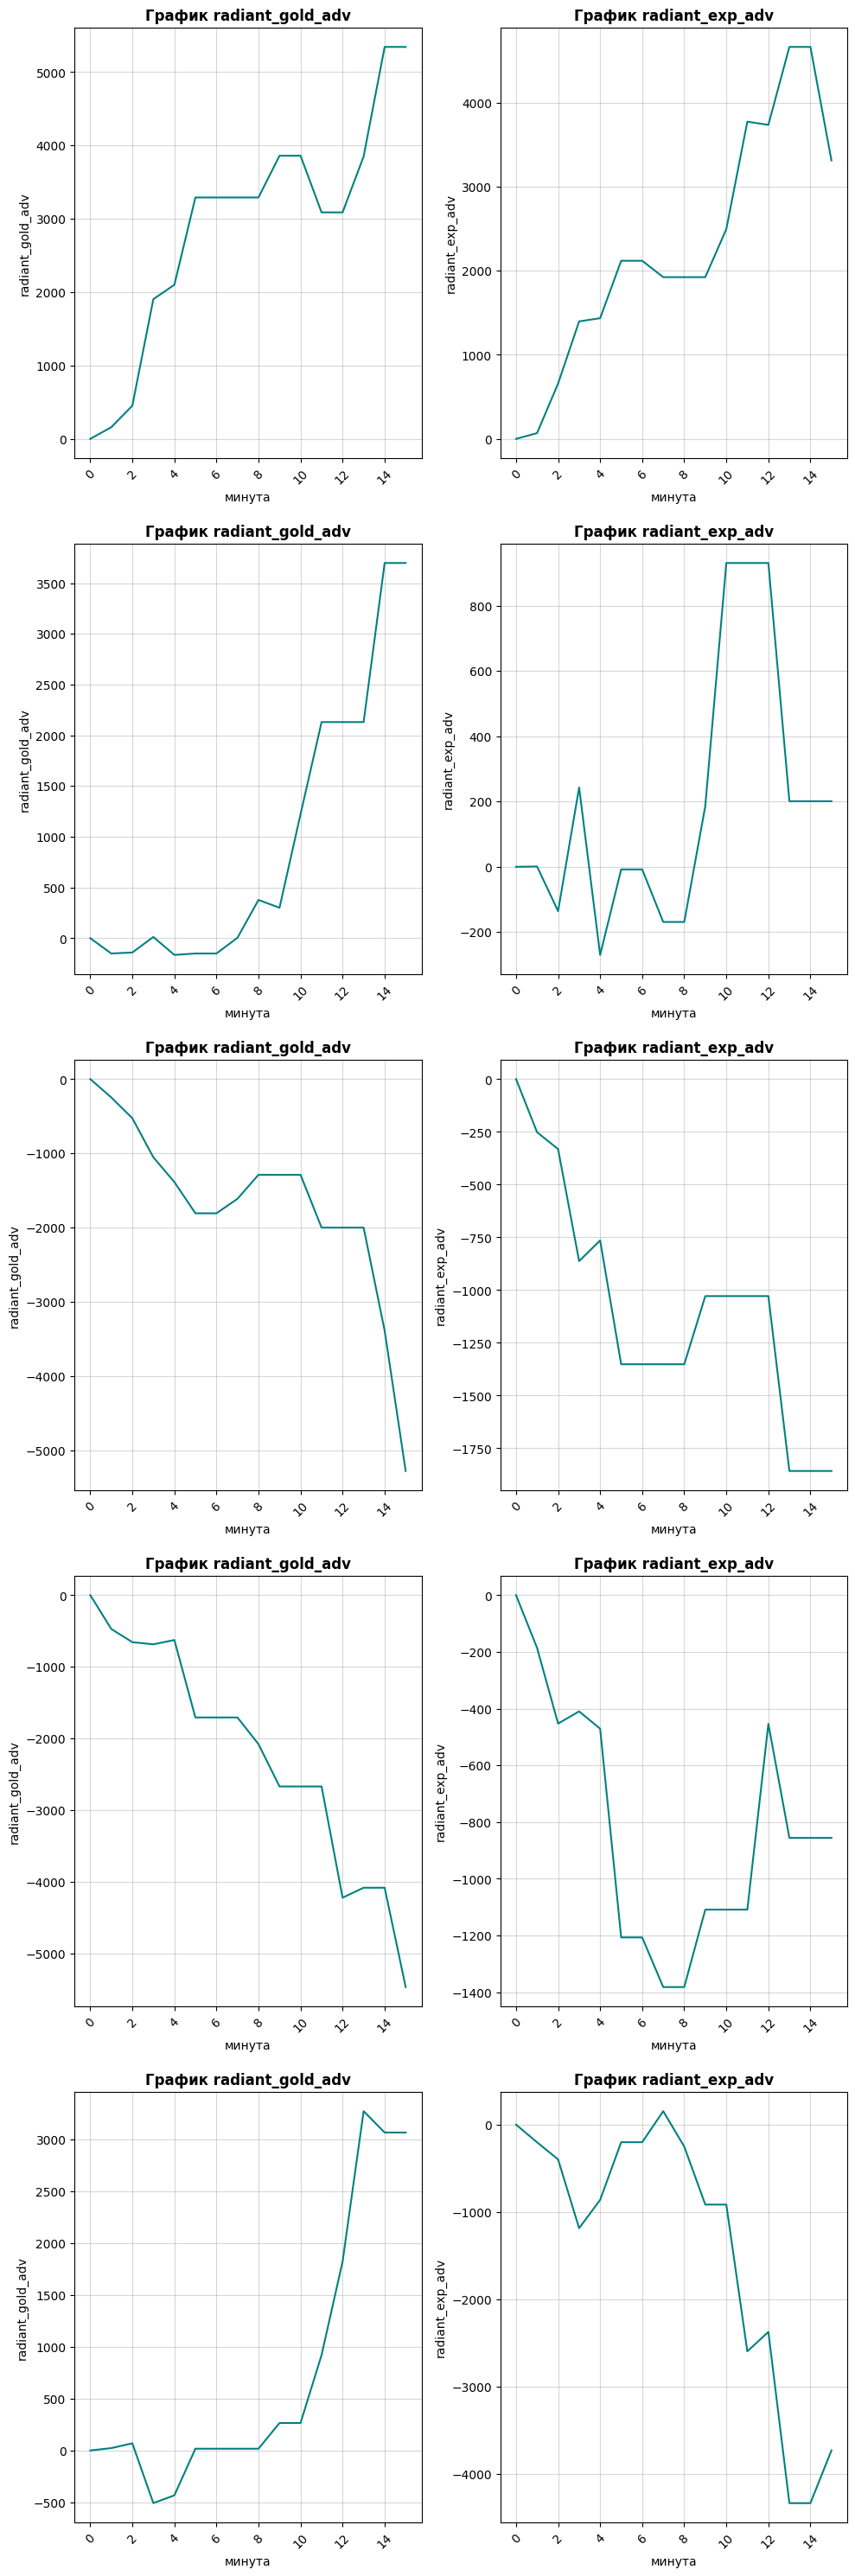

In [19]:
fig, ax = plt.subplots(5, 2, figsize=(10, 30))
for i in range(5):
    
    ax[i][0].plot(adv_df_clean['radiant_gold_adv'].iloc[i], color='teal')
    ax[i][0].set_title("График radiant_gold_adv", fontweight='bold')
    ax[i][0].set_xlabel("минута")
    ax[i][0].set_ylabel("radiant_gold_adv")
    ax[i][0].grid(alpha = 0.5)
    ax[i][0].tick_params(axis='x', rotation=45)

    ax[i][1].plot(adv_df_clean['radiant_exp_adv'].iloc[i], color='teal')
    ax[i][1].set_title("График radiant_exp_adv", fontweight='bold')
    ax[i][1].set_xlabel("минута")
    ax[i][1].set_ylabel("radiant_exp_adv")
    ax[i][1].grid(alpha = 0.5)
    ax[i][1].tick_params(axis='x', rotation=45)

plt.tight_layout()

Для начала возьмём простые агрегации. Можете взять те, что вам знакомы (статистики - среднее, стд и др.), можете взять фан факты в вашей любимой библиотеке для данных, например [тут](https://pandas.pydata.org/docs/user_guide/groupby.html#aggregation) или [тут](https://docs.pola.rs/api/python/stable/reference/expressions/aggregation.html).

Задание:
- взять 4 статистики из библиотеки, применить к обеим колонкам `_adv`, <font color="#f68c9d">**обдумать**</font>, почему именно они
- одну из статистику выше разбить по командам, и точно так же примените к колонкам (получится что-то типа `agg_xp` -> `agg_dire_xp`, `agg_radiant_xp`)

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Тут мы встаём на скользкую дорожку переобучения. Агрегаций можно сделать **очень** много. Добавьте их все, и ваша модель превратится в тыкву. Удобнее будет сразу бить их на группы, например `features_last`, `features_q25`, `features_kurtosis_dire_10min+` и так далее, в зависимости от степени упоротости

C другой стороны, агрегации это самая сильная группа фичей, и для десяточки лучше целиться именно в них

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какие агрегации берём?

**Ответ:**
Возьмем std(), квантили, skew(), var(). Вообще я скорее верю в тренды и значения в конце. И вообще всю кучу фичей накидаю сразу.
Сюда просто буду писать идеи фичей:
* Во первых можно обучить просто по значению в последнюю 15 минут
* можно по тренду в 10-15 минуте
* Добавить инфу по типу героев (типо керри и тд)
* можно сделать колонки для пар персов, где +1 эта пара за свет, -1 эта пара за тьму. Но может взорваться комп
* 15 - кол-во смен 
</div>

Обучите модель по агрегациям (одной группе или нескольким) + предыдущим фичам. Чтобы получить фулл балл, придётся показать, что хотя бы минимальный импрув есть, относительно бейзлайна

In [20]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
cnt_id_advdf_and_train = set(adv_df_clean['match_id'].unique()) & set(matches_df_train_enc2['match_id'].unique())
cnt_id_advdf_and_test = set(adv_df_clean['match_id'].unique()) & set(matches_df_test_enc2['match_id'].unique())

print(len(cnt_id_advdf_and_train), len(cnt_id_advdf_and_test), matches_df_train_enc2.shape, matches_df_test_enc2.shape)

198577 18645 (641090, 21) (59748, 20)


Во-первых, у нас для некоторых(около трети) тестовых данных есть инфа про график в первые 15 минут, это же классно

Добавим аггрегации

In [22]:
gold = {}
exp = {}

for _, row in adv_df_clean.iterrows():
    match_id = row['match_id']
    gold[match_id] = np.std(row['radiant_gold_adv'])
    exp[match_id] = np.std(row['radiant_exp_adv'])


meang = np.mean(list(gold.values()))
meane = np.mean(list(exp.values()))


matches_df_train_enc2['std_gold_adv_missing'] = matches_df_train_enc2['match_id'].map(gold).isna().astype(int)
matches_df_train_enc2['std_gold_adv'] = matches_df_train_enc2['match_id'].map(gold).fillna(0)

matches_df_train_enc2['std_exp_adv_missing'] = matches_df_train_enc2['match_id'].map(exp).isna().astype(int)
matches_df_train_enc2['std_exp_adv'] = matches_df_train_enc2['match_id'].map(exp).fillna(0)


matches_df_test_enc2['std_gold_adv_missing'] = matches_df_test_enc2['match_id'].map(gold).isna().astype(int)
matches_df_test_enc2['std_gold_adv'] = matches_df_test_enc2['match_id'].map(gold).fillna(0)

matches_df_test_enc2['std_exp_adv_missing'] = matches_df_test_enc2['match_id'].map(exp).isna().astype(int)
matches_df_test_enc2['std_exp_adv'] = matches_df_test_enc2['match_id'].map(exp).fillna(0)

In [24]:
adv_arrays = adv_df_clean[['match_id', 'radiant_gold_adv', 'radiant_exp_adv']].copy()

gold_skew = adv_arrays['radiant_gold_adv'].apply(pd.Series).skew(axis=1).fillna(0)
exp_skew = adv_arrays['radiant_exp_adv'].apply(pd.Series).skew(axis=1).fillna(0)

gold = dict(zip(adv_arrays['match_id'], gold_skew))
exp = dict(zip(adv_arrays['match_id'], exp_skew))

matches_df_train_enc2['skew_gold_adv'] = matches_df_train_enc2['match_id'].map(gold).fillna(0)
matches_df_train_enc2['skew_exp_adv'] = matches_df_train_enc2['match_id'].map(exp).fillna(0)

matches_df_test_enc2['skew_gold_adv'] = matches_df_test_enc2['match_id'].map(gold).fillna(0)
matches_df_test_enc2['skew_exp_adv'] = matches_df_test_enc2['match_id'].map(exp).fillna(0)

matches_df_train_enc2['skew_gold_adv_missing'] = matches_df_train_enc2['match_id'].map(gold).isna().astype(int)
matches_df_train_enc2['skew_exp_adv_missing'] = matches_df_train_enc2['match_id'].map(exp).isna().astype(int)
matches_df_test_enc2['skew_gold_adv_missing'] = matches_df_test_enc2['match_id'].map(gold).isna().astype(int)
matches_df_test_enc2['skew_exp_adv_missing'] = matches_df_test_enc2['match_id'].map(exp).isna().astype(int)

In [25]:
gold = {}
exp = {}

for _, row in adv_df_clean.iterrows():
    match_id = row['match_id']
    gold[match_id] = np.var(row['radiant_gold_adv'])
    exp[match_id] = np.var(row['radiant_exp_adv'])

meang = np.mean(list(gold.values()))
meane = np.mean(list(exp.values()))

matches_df_train_enc2['var_gold_adv'] = matches_df_train_enc2['match_id'].map(gold).fillna(0)
matches_df_train_enc2['var_exp_adv'] = matches_df_train_enc2['match_id'].map(exp).fillna(0)

matches_df_test_enc2['var_gold_adv'] = matches_df_test_enc2['match_id'].map(gold).fillna(0)
matches_df_test_enc2['var_exp_adv'] = matches_df_test_enc2['match_id'].map(exp).fillna(0)

matches_df_train_enc2['var_gold_adv_missing'] = matches_df_train_enc2['match_id'].map(gold).isna().astype(int)
matches_df_train_enc2['var_exp_adv_missing'] = matches_df_train_enc2['match_id'].map(exp).isna().astype(int)
matches_df_test_enc2['var_gold_adv_missing'] = matches_df_test_enc2['match_id'].map(gold).isna().astype(int)
matches_df_test_enc2['var_exp_adv_missing'] = matches_df_test_enc2['match_id'].map(exp).isna().astype(int)

In [26]:
gold = {}
exp = {}

for _, row in adv_df_clean.iterrows():
    match_id = row['match_id']
    gold[match_id] = np.quantile(row['radiant_gold_adv'], 0.25)
    exp[match_id] = np.quantile(row['radiant_exp_adv'], 0.25)

meang = np.mean(list(gold.values()))
meane = np.mean(list(exp.values()))

matches_df_train_enc2['quantile_gold_adv'] = matches_df_train_enc2['match_id'].map(gold).fillna(0)
matches_df_train_enc2['quantile_exp_adv'] = matches_df_train_enc2['match_id'].map(exp).fillna(0)

matches_df_test_enc2['quantile_gold_adv'] = matches_df_test_enc2['match_id'].map(gold).fillna(0)
matches_df_test_enc2['quantile_exp_adv'] = matches_df_test_enc2['match_id'].map(exp).fillna(0)

matches_df_train_enc2['quantile_gold_adv_missing'] = matches_df_train_enc2['match_id'].map(gold).isna().astype(int)
matches_df_train_enc2['quantile_exp_adv_missing'] = matches_df_train_enc2['match_id'].map(exp).isna().astype(int)
matches_df_test_enc2['quantile_gold_adv_missing'] = matches_df_test_enc2['match_id'].map(gold).isna().astype(int)
matches_df_test_enc2['quantile_exp_adv_missing'] = matches_df_test_enc2['match_id'].map(exp).isna().astype(int)

matches_df_train_enc2

,match_id,date,region_Europe West,region_South Africa,region_Middle East,region_US East,region_Europe East,region_South America,region_China,region_US West,...,skew_gold_adv_missing,skew_exp_adv_missing,var_gold_adv,var_exp_adv,var_gold_adv_missing,var_exp_adv_missing,quantile_gold_adv,quantile_exp_adv,quantile_gold_adv_missing,quantile_exp_adv_missing
147802,176828,2024-01-01,1,0,0,0,0,0,0,0,...,1,1,0.000000e+00,0.000000e+00,1,1,0.00,0.0,1,1
442520,529827,2024-01-01,0,0,1,0,0,0,0,0,...,0,0,3.790391e+05,1.690818e+05,0,0,-322.00,-596.5,0,0
274960,329224,2024-01-01,1,0,0,0,0,0,0,0,...,1,1,0.000000e+00,0.000000e+00,1,1,0.00,0.0,1,1
415926,497876,2024-01-01,0,0,1,0,0,0,0,0,...,0,0,7.270474e+05,1.546098e+06,0,0,-285.75,137.0,0,0
451726,540899,2024-01-01,0,0,0,0,0,0,0,0,...,0,0,5.922132e+05,1.712079e+06,0,0,273.25,720.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79884,95515,2024-11-30,1,0,0,0,0,0,0,0,...,1,1,0.000000e+00,0.000000e+00,1,1,0.00,0.0,1,1
484099,579725,2024-11-30,1,0,0,0,0,0,0,0,...,0,0,1.222311e+06,1.115916e+06,0,0,-553.25,-1996.0,0,0
335937,402188,2024-11-30,0,0,0,0,0,1,0,0,...,0,0,1.599391e+06,2.301092e+06,0,0,-11.25,-2098.0,0,0
332869,398524,2024-11-30,1,0,0,0,0,0,0,0,...,0,0,7.457550e+06,4.368694e+05,0,0,610.75,211.5,0,0


In [31]:
feature_cols = ['match_id', 'region_Europe West', 'region_South Africa',
                'region_Middle East', 'region_US East', 'region_Europe East',
                'region_South America', 'region_China', 'region_US West',
                'region_Australia', 'avg_mmr', 'mmr_missing', 
               'std_gold_adv', 'std_exp_adv', 'var_gold_adv', 'var_exp_adv',
               'quantile_gold_adv', 'quantile_exp_adv', 'skew_gold_adv', 'skew_exp_adv',
               'quantile_gold_adv_missing', 'quantile_exp_adv_missing',
               'var_gold_adv_missing', 'var_exp_adv_missing', 'skew_gold_adv_missing',
               'skew_exp_adv_missing', 'std_gold_adv_missing', 'std_exp_adv_missing']

pipeline = MyPipeline(matches_df_train_enc2, matches_df_test_enc2, feature_cols, matr, target_col=target)
pipeline.cross_validate()
pipeline.predict()
model_registry.register_model(feature_cols, matr.shape, pipeline.model_params, res)

ФОЛД 1
ФОЛД 2
ФОЛД 3
ФОЛД 4
ФОЛД 5
результаты, кросс валидации
   fold  accuracy  precision  recall      f1  roc_auc    gini
0     1    0.6409     0.6416  0.6409  0.6412   0.6975  0.3951
1     2    0.6366     0.6365  0.6366  0.6366   0.6906  0.3812
2     3    0.6334     0.6344  0.6334  0.6336   0.6878  0.3756
3     4    0.6345     0.6346  0.6345  0.6345   0.6895  0.3789
4     5    0.6377     0.6376  0.6377  0.6376   0.6910  0.3820

Средние значения:
  Accuracy:  0.6366 +/- 0.0026
  Precision: 0.6370 +/- 0.0026
  Recall:    0.6366 +/- 0.0026
  F1-score:  0.6367 +/- 0.0027
  ROC-AUC:   0.6913 +/- 0.0033
  gini:      0.3826 +/- 0.0066
Сохранено resi.csv 1773353440.4439585


datetime.datetime(2026, 3, 12, 22, 10, 40, 446872)

Ура, джини на валидации выросло до 0.3825. успех. ща еще другие фичи отдельно попробуем.

попробуем добавить столбец просто с ластовым значением в массиве

In [32]:
def get_last_value(arr):
    if len(arr) > 0:
        return arr[-1]
    return 0

last_gold = {}
last_exp = {}

for _, row in adv_df_clean.iterrows():
    match_id = row['match_id']
    last_gold[match_id] = get_last_value(row['radiant_gold_adv'])
    last_exp[match_id] = get_last_value(row['radiant_exp_adv'])

matches_df_train_enc2['last_gold_adv'] = matches_df_train_enc2['match_id'].map(last_gold).fillna(0)
matches_df_train_enc2['last_exp_adv'] = matches_df_train_enc2['match_id'].map(last_exp).fillna(0)

matches_df_test_enc2['last_gold_adv'] = matches_df_test_enc2['match_id'].map(last_gold).fillna(0)
matches_df_test_enc2['last_exp_adv'] = matches_df_test_enc2['match_id'].map(last_exp).fillna(0)

matches_df_train_enc2['last_gold_adv_missing'] = matches_df_train_enc2['match_id'].map(last_gold).isna().astype(int)
matches_df_train_enc2['last_exp_adv_missing'] = matches_df_train_enc2['match_id'].map(last_exp).isna().astype(int)
matches_df_test_enc2['last_gold_adv_missing'] = matches_df_test_enc2['match_id'].map(last_gold).isna().astype(int)
matches_df_test_enc2['last_exp_adv_missing'] = matches_df_test_enc2['match_id'].map(last_exp).isna().astype(int)

matches_df_train_enc2

,match_id,date,region_Europe West,region_South Africa,region_Middle East,region_US East,region_Europe East,region_South America,region_China,region_US West,...,var_gold_adv_missing,var_exp_adv_missing,quantile_gold_adv,quantile_exp_adv,quantile_gold_adv_missing,quantile_exp_adv_missing,last_gold_adv,last_exp_adv,last_gold_adv_missing,last_exp_adv_missing
147802,176828,2024-01-01,1,0,0,0,0,0,0,0,...,1,1,0.00,0.0,1,1,0.0,0.0,1,1
442520,529827,2024-01-01,0,0,1,0,0,0,0,0,...,0,0,-322.00,-596.5,0,0,1292.0,-241.0,0,0
274960,329224,2024-01-01,1,0,0,0,0,0,0,0,...,1,1,0.00,0.0,1,1,0.0,0.0,1,1
415926,497876,2024-01-01,0,0,1,0,0,0,0,0,...,0,0,-285.75,137.0,0,0,-1994.0,2766.0,0,0
451726,540899,2024-01-01,0,0,0,0,0,0,0,0,...,0,0,273.25,720.0,0,0,314.0,5297.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79884,95515,2024-11-30,1,0,0,0,0,0,0,0,...,1,1,0.00,0.0,1,1,0.0,0.0,1,1
484099,579725,2024-11-30,1,0,0,0,0,0,0,0,...,0,0,-553.25,-1996.0,0,0,-2717.0,231.0,0,0
335937,402188,2024-11-30,0,0,0,0,0,1,0,0,...,0,0,-11.25,-2098.0,0,0,2099.0,-4370.0,0,0
332869,398524,2024-11-30,1,0,0,0,0,0,0,0,...,0,0,610.75,211.5,0,0,10051.0,1249.0,0,0


Затестим нашим пайплайном из последней части этого ноутбука

In [34]:
feature_cols = ['match_id', 'region_Europe West', 'region_South Africa',
                'region_Middle East', 'region_US East', 'region_Europe East',
                'region_South America', 'region_China', 'region_US West',
                'region_Australia', 'avg_mmr', 'mmr_missing', 'last_gold_adv', 'last_exp_adv',
               'last_gold_adv_missing', 'last_exp_adv_missing']

pipeline = MyPipeline(matches_df_train_enc2, matches_df_test_enc2, feature_cols, matr, target_col=target)
pipeline.cross_validate()
pipeline.predict()
model_registry.register_model(feature_cols, matr.shape, pipeline.model_params, res)

ФОЛД 1
ФОЛД 2
ФОЛД 3
ФОЛД 4
ФОЛД 5
результаты, кросс валидации
   fold  accuracy  precision  recall      f1  roc_auc    gini
0     1    0.6414     0.6422  0.6414  0.6416   0.6987  0.3974
1     2    0.6423     0.6423  0.6423  0.6423   0.6999  0.3999
2     3    0.6401     0.6411  0.6401  0.6403   0.6989  0.3979
3     4    0.6424     0.6424  0.6424  0.6423   0.7005  0.4011
4     5    0.6427     0.6427  0.6427  0.6427   0.6999  0.3998

Средние значения:
  Accuracy:  0.6418 +/- 0.0009
  Precision: 0.6421 +/- 0.0005
  Recall:    0.6418 +/- 0.0009
  F1-score:  0.6418 +/- 0.0008
  ROC-AUC:   0.6996 +/- 0.0007
  gini:      0.3992 +/- 0.0014
Сохранено resi.csv 1773353570.205693


datetime.datetime(2026, 3, 12, 22, 12, 50, 208590)

УРА. 0.395 на валидации и 0.369 на тесте в соревке. Трешхолды пройдены, +вайб

#### 📈 **Задание 5.2. Тренд** (0.5 балла)


<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** для чего нам вообще тренд? Полезная ли это агрегация?

**Ответ:**
ну очев полезная, но полезность фичи в теории оценить сложно, надо на практике запустить)))

А так, тренд помогает оценить насколько команда "набирает" преимущество. Что-то типо производной 

</div>

Агрегировать можно и вещи несколько более прикольные, чем те, что есть в основном функционале. Делать это мы будем, как вы наверняка догадались, трансформером, ну а чем же ещё. Что он умеет?

1. Принимает на вход функцию колонку и <font color="#cb9255">**параметры**</font> на ваш вкус, как минимум `method`, метод расчёта `slope`
2. Выделяет коэффициент наклона (`slope`, он же $\alpha$) при помощи одного из методов:
   - `'delta'`: разность первого и последнего значений $|x_{\max} - x_{\min}|$
   - `'OLS'`: линейная регрессия, обученная методом МНК $(X^TX)^{-1}X^Ty$
   - альтернативный метод, порождённый вашей бурной фантазией
3. Считает `r2` и `intercept` для одного advantage (если что это тоже могут быть наши фичи!)

In [35]:
from typing import Iterable
from sklearn.linear_model import LinearRegression

class TrendTransformer:

    def __init__(self, columns: Iterable[str], method = 'OLS'):
        self.columns = columns
        self.method = method

    def fit(self, X, y=None):
        pass

    def _calculate_slope_ols(self, values):
        if len(values) < 2:
            return 0, 0
        
        x = np.arange(len(values))
        y = np.array(values)
        
        slope = np.sum(x * y) / np.sum(x * x)
        
        y_pred = slope * x
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        
        return slope, r2

    def _calc_last5(self, values):
        if len(values) < 5:
            return 0
        return values[-1] - values[-5]

    def _calc_start(self, values):
        if len(values) < 5:
            return 0
        return values[5]

    def _calc_mid(self, values):
        if len(values) < 10:
            return 0
        return values[9] - values[4]

    def _calc_fl(self, values):
        if len(values) < 10:
            return 0
        if (values[-1] - values[-5]) > (values[5] - values[1]):
            return 1

    def transform(self, X, y=None):
        result = pd.DataFrame({
            'match_id': X['match_id'].values
        })
        
        for col in self.columns:
            slopes = []
            r2s = []
            
            for values in X[col]:
                if self.method == 'OLS':
                    slope, r2 = self._calculate_slope_ols(values)
                    slopes.append(slope)
                    r2s.append(r2)
                if self.method == 'last5':
                    slope = self._calc_last5(values)
                    slopes.append(slope)
                if self.method == 'start':
                    slope = self._calc_start(values)
                    slopes.append(slope)
                if self.method == 'mid':
                    slope = self._calc_mid(values)
                    slopes.append(slope)
                if self.method == 'fl':
                    slope = self._calc_fl(values)
                    slopes.append(slope)
            
            result[f'{col}_slope'] = slopes
            if self.method == 'OLS':
                result[f'{col}_r2'] = r2s
        
        return result

Реализуйте трансформер. Критерий успеха, вновь, качество — фича должна помочь, хотя бы на долю пункта

In [36]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

trend_transformer = TrendTransformer(
    columns=['radiant_gold_adv', 'radiant_exp_adv'],
    method='OLS',
)

trend_features = trend_transformer.transform(adv_df_clean)
trend_features

,match_id,radiant_gold_adv_slope,radiant_gold_adv_r2,radiant_exp_adv_slope,radiant_exp_adv_r2
0,526846,362.896774,0.768781,296.384677,0.860306
1,511496,160.619355,0.625213,30.317742,0.232400
2,15301,-221.522581,0.656559,-131.428226,0.575164
3,578050,-303.613710,0.932594,-91.034677,-0.128713
4,533238,133.808871,0.524368,-208.412097,0.616242
...,...,...,...,...,...
238034,585277,455.391129,0.744466,54.721774,0.193527
238035,519943,0.559677,-0.090677,52.042742,-0.284888
238036,501459,86.236290,0.202778,67.451613,0.201917
238037,602640,-20.120161,0.092378,183.777419,0.328124


In [37]:
gold_slope = {}
exp_slope = {}

for _, row in trend_features.iterrows():
    match_id = row['match_id']
    gold_slope[match_id] = row['radiant_gold_adv_slope']
    exp_slope[match_id] = row['radiant_exp_adv_slope']

meang = np.mean(list(gold_slope.values()))
meane = np.mean(list(exp_slope.values()))

matches_df_train_enc2['radiant_gold_adv_slope'] = matches_df_train_enc2['match_id'].map(gold_slope).fillna(0)
matches_df_train_enc2['radiant_exp_adv_slope'] = matches_df_train_enc2['match_id'].map(exp_slope).fillna(0)

matches_df_test_enc2['radiant_gold_adv_slope'] = matches_df_test_enc2['match_id'].map(gold_slope).fillna(0)
matches_df_test_enc2['radiant_exp_adv_slope'] = matches_df_test_enc2['match_id'].map(exp_slope).fillna(0)

matches_df_train_enc2['radiant_gold_adv_slope_missing'] = matches_df_train_enc2['match_id'].map(gold_slope).isna().astype(int)
matches_df_train_enc2['radiant_exp_adv_slope_missing'] = matches_df_train_enc2['match_id'].map(exp_slope).isna().astype(int)
matches_df_test_enc2['radiant_gold_adv_slope_missing'] = matches_df_test_enc2['match_id'].map(gold_slope).isna().astype(int)
matches_df_test_enc2['radiant_exp_adv_slope_missing'] = matches_df_test_enc2['match_id'].map(exp_slope).isna().astype(int)

matches_df_train_enc2

,match_id,date,region_Europe West,region_South Africa,region_Middle East,region_US East,region_Europe East,region_South America,region_China,region_US West,...,quantile_gold_adv_missing,quantile_exp_adv_missing,last_gold_adv,last_exp_adv,last_gold_adv_missing,last_exp_adv_missing,radiant_gold_adv_slope,radiant_exp_adv_slope,radiant_gold_adv_slope_missing,radiant_exp_adv_slope_missing
147802,176828,2024-01-01,1,0,0,0,0,0,0,0,...,1,1,0.0,0.0,1,1,0.000000,0.000000,1,1
442520,529827,2024-01-01,0,0,1,0,0,0,0,0,...,0,0,1292.0,-241.0,0,0,31.513710,-34.304839,0,0
274960,329224,2024-01-01,1,0,0,0,0,0,0,0,...,1,1,0.0,0.0,1,1,0.000000,0.000000,1,1
415926,497876,2024-01-01,0,0,1,0,0,0,0,0,...,0,0,-1994.0,2766.0,0,0,-20.237097,161.838710,0,0
451726,540899,2024-01-01,0,0,0,0,0,0,0,0,...,0,0,314.0,5297.0,0,0,89.712903,211.147581,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79884,95515,2024-11-30,1,0,0,0,0,0,0,0,...,1,1,0.0,0.0,1,1,0.000000,0.000000,1,1
484099,579725,2024-11-30,1,0,0,0,0,0,0,0,...,0,0,-2717.0,231.0,0,0,-118.642742,-153.619355,0,0
335937,402188,2024-11-30,0,0,0,0,0,1,0,0,...,0,0,2099.0,-4370.0,0,0,162.701613,-235.505645,0,0
332869,398524,2024-11-30,1,0,0,0,0,0,0,0,...,0,0,10051.0,1249.0,0,0,365.125806,94.204839,0,0


затестим без r^2

In [ ]:
feature_cols = ['match_id', 'region_Europe West', 'region_South Africa',
                'region_Middle East', 'region_US East', 'region_Europe East',
                'region_South America', 'region_China', 'region_US West',
                'region_Australia', 'avg_mmr', 'mmr_missing', 'last_gold_adv', 'last_exp_adv',
               'radiant_gold_adv_slope', 'radiant_exp_adv_slope']

pipeline = MyPipeline(matches_df_train_enc2, matches_df_test_enc2, feature_cols, matr, target_col=target)
pipeline.cross_validate(False)
pipeline.predict()
model_registry.register_model(feature_cols, matr.shape, pipeline.model_params, res)

УРааааа валидация выросла с 0.3947 до 0.3962. И тест вырос с 0.36921 до 0.36999

Ща еще r^2 добавим

In [38]:
gold_slope = {}
exp_slope = {}

for _, row in trend_features.iterrows():
    match_id = row['match_id']
    gold_slope[match_id] = row['radiant_gold_adv_r2']
    exp_slope[match_id] = row['radiant_exp_adv_r2']

meang = np.mean(list(gold_slope.values()))
meane = np.mean(list(exp_slope.values()))

matches_df_train_enc2['radiant_gold_adv_r2'] = matches_df_train_enc2['match_id'].map(gold_slope).fillna(0)
matches_df_train_enc2['radiant_exp_adv_r2'] = matches_df_train_enc2['match_id'].map(exp_slope).fillna(0)

matches_df_test_enc2['radiant_gold_adv_r2'] = matches_df_test_enc2['match_id'].map(gold_slope).fillna(0)
matches_df_test_enc2['radiant_exp_adv_r2'] = matches_df_test_enc2['match_id'].map(exp_slope).fillna(0)

matches_df_train_enc2['radiant_gold_adv_r2_missing'] = matches_df_train_enc2['match_id'].map(gold_slope).isna().astype(int)
matches_df_train_enc2['radiant_exp_adv_r2_missing'] = matches_df_train_enc2['match_id'].map(exp_slope).isna().astype(int)
matches_df_test_enc2['radiant_gold_adv_r2_missing'] = matches_df_test_enc2['match_id'].map(gold_slope).isna().astype(int)
matches_df_test_enc2['radiant_exp_adv_r2_missing'] = matches_df_test_enc2['match_id'].map(exp_slope).isna().astype(int)

matches_df_train_enc2

,match_id,date,region_Europe West,region_South Africa,region_Middle East,region_US East,region_Europe East,region_South America,region_China,region_US West,...,last_gold_adv_missing,last_exp_adv_missing,radiant_gold_adv_slope,radiant_exp_adv_slope,radiant_gold_adv_slope_missing,radiant_exp_adv_slope_missing,radiant_gold_adv_r2,radiant_exp_adv_r2,radiant_gold_adv_r2_missing,radiant_exp_adv_r2_missing
147802,176828,2024-01-01,1,0,0,0,0,0,0,0,...,1,1,0.000000,0.000000,1,1,0.000000,0.000000,1,1
442520,529827,2024-01-01,0,0,1,0,0,0,0,0,...,0,0,31.513710,-34.304839,0,0,-0.258047,0.089082,0,0
274960,329224,2024-01-01,1,0,0,0,0,0,0,0,...,1,1,0.000000,0.000000,1,1,0.000000,0.000000,1,1
415926,497876,2024-01-01,0,0,1,0,0,0,0,0,...,0,0,-20.237097,161.838710,0,0,0.043429,0.613578,0,0
451726,540899,2024-01-01,0,0,0,0,0,0,0,0,...,0,0,89.712903,211.147581,0,0,-0.218047,0.676200,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79884,95515,2024-11-30,1,0,0,0,0,0,0,0,...,1,1,0.000000,0.000000,1,1,0.000000,0.000000,1,1
484099,579725,2024-11-30,1,0,0,0,0,0,0,0,...,0,0,-118.642742,-153.619355,0,0,0.491536,0.350129,0,0
335937,402188,2024-11-30,0,0,0,0,0,1,0,0,...,0,0,162.701613,-235.505645,0,0,0.604426,0.773807,0,0
332869,398524,2024-11-30,1,0,0,0,0,0,0,0,...,0,0,365.125806,94.204839,0,0,0.654661,0.386472,0,0


In [ ]:
feature_cols = ['match_id', 'region_Europe West', 'region_South Africa',
                'region_Middle East', 'region_US East', 'region_Europe East',
                'region_South America', 'region_China', 'region_US West',
                'region_Australia', 'avg_mmr', 'mmr_missing', 'last_gold_adv', 'last_exp_adv',
               'radiant_gold_adv_slope', 'radiant_exp_adv_slope', 'radiant_gold_adv_r2', 'radiant_exp_adv_r2']

pipeline = MyPipeline(matches_df_train_enc2, matches_df_test_enc2, feature_cols, matr, target_col=target)
pipeline.cross_validate(False)
pipeline.predict()
model_registry.register_model(feature_cols, matr.shape, pipeline.model_params, res)

Джини на валидации с 0.3962 вырос до 0.3975. Ура ура. на тесте с 0.36999 до 0.37160. ДЭЭЭНС

Добавим наклон в последние 5 минут

In [ ]:
trend_transformer = TrendTransformer(
    columns=['radiant_gold_adv', 'radiant_exp_adv'],
    method='last5',
)

trend_features = trend_transformer.transform(adv_df_clean)
trend_features

In [39]:
gold_slope = {}
exp_slope = {}

for _, row in trend_features.iterrows():
    match_id = row['match_id']
    gold_slope[match_id] = row['radiant_gold_adv_slope']
    exp_slope[match_id] = row['radiant_exp_adv_slope']

matches_df_train_enc2['radiant_gold_adv_last5'] = matches_df_train_enc2['match_id'].map(gold_slope).fillna(0)
matches_df_train_enc2['radiant_exp_adv_last5'] = matches_df_train_enc2['match_id'].map(exp_slope).fillna(0)

matches_df_test_enc2['radiant_gold_adv_last5'] = matches_df_test_enc2['match_id'].map(gold_slope).fillna(0)
matches_df_test_enc2['radiant_exp_adv_last5'] = matches_df_test_enc2['match_id'].map(exp_slope).fillna(0)

matches_df_train_enc2['radiant_gold_adv_last5_missing'] = matches_df_train_enc2['match_id'].map(gold_slope).isna().astype(int)
matches_df_train_enc2['radiant_exp_adv_last5_missing'] = matches_df_train_enc2['match_id'].map(exp_slope).isna().astype(int)
matches_df_test_enc2['radiant_gold_adv_last5_missing'] = matches_df_test_enc2['match_id'].map(gold_slope).isna().astype(int)
matches_df_test_enc2['radiant_exp_adv_last5_missing'] = matches_df_test_enc2['match_id'].map(exp_slope).isna().astype(int)

matches_df_train_enc2

,match_id,date,region_Europe West,region_South Africa,region_Middle East,region_US East,region_Europe East,region_South America,region_China,region_US West,...,radiant_gold_adv_slope_missing,radiant_exp_adv_slope_missing,radiant_gold_adv_r2,radiant_exp_adv_r2,radiant_gold_adv_r2_missing,radiant_exp_adv_r2_missing,radiant_gold_adv_last5,radiant_exp_adv_last5,radiant_gold_adv_last5_missing,radiant_exp_adv_last5_missing
147802,176828,2024-01-01,1,0,0,0,0,0,0,0,...,1,1,0.000000,0.000000,1,1,0.000000,0.000000,1,1
442520,529827,2024-01-01,0,0,1,0,0,0,0,0,...,0,0,-0.258047,0.089082,0,0,31.513710,-34.304839,0,0
274960,329224,2024-01-01,1,0,0,0,0,0,0,0,...,1,1,0.000000,0.000000,1,1,0.000000,0.000000,1,1
415926,497876,2024-01-01,0,0,1,0,0,0,0,0,...,0,0,0.043429,0.613578,0,0,-20.237097,161.838710,0,0
451726,540899,2024-01-01,0,0,0,0,0,0,0,0,...,0,0,-0.218047,0.676200,0,0,89.712903,211.147581,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79884,95515,2024-11-30,1,0,0,0,0,0,0,0,...,1,1,0.000000,0.000000,1,1,0.000000,0.000000,1,1
484099,579725,2024-11-30,1,0,0,0,0,0,0,0,...,0,0,0.491536,0.350129,0,0,-118.642742,-153.619355,0,0
335937,402188,2024-11-30,0,0,0,0,0,1,0,0,...,0,0,0.604426,0.773807,0,0,162.701613,-235.505645,0,0
332869,398524,2024-11-30,1,0,0,0,0,0,0,0,...,0,0,0.654661,0.386472,0,0,365.125806,94.204839,0,0


In [40]:
feature_cols = ['match_id', 'region_Europe West', 'region_South Africa',
                'region_Middle East', 'region_US East', 'region_Europe East',
                'region_South America', 'region_China', 'region_US West',
                'region_Australia', 'avg_mmr', 'mmr_missing', 'last_gold_adv', 'last_exp_adv',
               'radiant_gold_adv_slope', 'radiant_exp_adv_slope', 'radiant_gold_adv_r2', 'radiant_exp_adv_r2',
               'radiant_gold_adv_last5', 'radiant_exp_adv_last5',
               'radiant_gold_adv_last5_missing', 'radiant_exp_adv_last5_missing',
               'radiant_gold_adv_r2_missing', 'radiant_exp_adv_r2_missing',
               'radiant_gold_adv_slope_missing', 'radiant_exp_adv_slope_missing',
               'last_gold_adv_missing', 'last_exp_adv_missing']

pipeline = MyPipeline(matches_df_train_enc2, matches_df_test_enc2, feature_cols, matr, target_col=target)
pipeline.cross_validate()
pipeline.predict()
model_registry.register_model(feature_cols, matr.shape, pipeline.model_params, res)

ФОЛД 1
ФОЛД 2
ФОЛД 3
ФОЛД 4
ФОЛД 5
результаты, кросс валидации
   fold  accuracy  precision  recall      f1  roc_auc    gini
0     1    0.6421     0.6429  0.6421  0.6423   0.7002  0.4003
1     2    0.6425     0.6425  0.6425  0.6425   0.7004  0.4008
2     3    0.6404     0.6413  0.6404  0.6406   0.6993  0.3986
3     4    0.6426     0.6426  0.6426  0.6425   0.7009  0.4017
4     5    0.6427     0.6428  0.6427  0.6427   0.7004  0.4008

Средние значения:
  Accuracy:  0.6421 +/- 0.0009
  Precision: 0.6424 +/- 0.0006
  Recall:    0.6421 +/- 0.0009
  F1-score:  0.6421 +/- 0.0008
  ROC-AUC:   0.7002 +/- 0.0005
  gini:      0.4004 +/- 0.0010
Сохранено resi.csv 1773353960.4707482


datetime.datetime(2026, 3, 12, 22, 19, 20, 474269)

Джини на валидации с  0.3975 вырос до 0.3994. еще одна гойда. на тесте с 0.37160 до 0.37468. ДЭЭЭНС

### Итого ща все вместе:

In [ ]:
feature_cols = ['match_id', 'region_Europe West', 'region_South Africa',
                'region_Middle East', 'region_US East', 'region_Europe East',
                'region_South America', 'region_China', 'region_US West',
                'region_Australia', 'avg_mmr', 'mmr_missing', 'last_gold_adv', 'last_exp_adv',
               'radiant_gold_adv_slope', 'radiant_exp_adv_slope', 'radiant_gold_adv_r2',
                'radiant_exp_adv_r2',
               'radiant_gold_adv_last5', 'radiant_exp_adv_last5',
               'std_gold_adv', 'std_exp_adv', 'var_gold_adv', 'var_exp_adv',
               'quantile_gold_adv', 'quantile_exp_adv', 'skew_gold_adv', 'skew_exp_adv',
               'radiant_gold_adv_last5_missing', 'radiant_exp_adv_last5_missing',
               'radiant_gold_adv_r2_missing', 'radiant_exp_adv_r2_missing',
               'radiant_gold_adv_slope_missing', 'radiant_exp_adv_slope_missing',
               'last_gold_adv_missing', 'last_exp_adv_missing',
               ]

pipeline = MyPipeline(matches_df_train_enc2, matches_df_test_enc2, feature_cols, matr, target_col=target)
pipeline.cross_validate()
pipeline.predict()
model_registry.register_model(feature_cols, matr.shape, pipeline.model_params, res)

ФОЛД 1


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


ФОЛД 2


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


ФОЛД 3


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


ФОЛД 4
ФОЛД 5


уфффффф 0.4031 на валидации. и 0.37919 на тесте. кайф.

Чтобы не засорять тут ноутбук и облегчить проверку, я остальные фичи добавлю в самом конце ноутбука.

### **Часть 6. Около ML** (2 балла) <img height=25px width=35px align="center" src="https://media1.tenor.com/m/72ScVNgTGpYAAAAC/kaneki-tokyo-ghoul.gif"></img>


#### **Задание 6.1. Пайплайн** (0.5 балла)

Работать в ноутбуках становится экспоненциально тяжелее по мере разрастания модели. Чтобы немножко упорядочить хаос, вам предлагается засунуть всё в один пайплайн. Критерии:

- функция или класс (может понравиться `ColumnTransformer` и `Pipeline`)
- возможность нажать одну кнопку, чтобы запустить пайплайн, уйти пить пиво и вернуться к уже готовому submission для Kaggle
- возможность передать флаги (какие фичи добавляем) и параметры (если есть разные варианты сбора параметров)
- включает в себя все пункты, к которым вы прикоснулись в рамках домашнего задания

А вот как именно это делать — дело ваше, для себя же стараетесь

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
import time
from sklearn.preprocessing import RobustScaler



class MyPipeline:
    def __init__(self, train, test, feature_cols, hero_matrix, target_col='target', model_params=None):
        self.feature_cols = feature_cols
        self.hero_matrix = hero_matrix
        self.target_col = target_col
        self.model_params = model_params or {
            'C': 0.029743331803711446,
            'solver': 'lbfgs',
            'penalty': 'l2',
            'max_iter': 1800,
            'random_state': 42,
            'class_weight': 'balanced'
        }

        self.y = train.set_index('match_id')[self.target_col]
        
        train = train[self.feature_cols].copy()
        train = (train
            .set_index('match_id')
            .join(self.hero_matrix, how='left')
            .fillna(0)
        )
        self.train = train
        
        test = test[self.feature_cols].copy()
        test = (test
            .set_index('match_id')
            .join(self.hero_matrix, how='left')
            .fillna(0)
        )

        self.test = test
        
    
    def scaler_mmr(self, X_train, X_test):
        scaler2 = StandardScaler()
    
        X_train_scaled = X_train.copy()
        X_test_scaled = X_test.copy()

        scale_cols = ['avg_mmr', 'last_gold_adv', 'last_exp_adv', 'radiant_gold_adv_slope',
                     'radiant_exp_adv_slope', 'radiant_gold_adv_r2', 'radiant_exp_adv_r2',
                     'radiant_gold_adv_last5', 'radiant_exp_adv_last5',
                     'std_gold_adv', 'std_exp_adv', 'var_gold_adv', 'var_exp_adv',
                   'quantile_gold_adv', 'quantile_exp_adv', 'skew_gold_adv', 'skew_exp_adv',
                     'cross_zero_gold', 'cross_zero_exp',
                     'radiant_str', 'dire_str', 'radiant_agi', 'dire_agi', 
            'radiant_int', 'dire_int', 'radiant_all', 'dire_all',
            'radiant_Melee', 'dire_Melee', 'radiant_Ranged', 'dire_Ranged',
                     'chat_razn', 'radiant_gold_adv_start', 'radiant_exp_adv_start',
                     'radiant_gold_adv_mid', 'radiant_exp_adv_mid',
                     'radiant_gold_adv_fl', 'radiant_exp_adv_fl',
                     'quantile1_gold_adv', 'quantile1_exp_adv']
    
        for col in scale_cols:
            if col in X_train.columns:
                scaler = RobustScaler()
                scaler.fit(X_train[[col]])
                X_train_scaled[col] = scaler.transform(X_train[[col]])
                X_test_scaled[col] = scaler.transform(X_test[[col]])
        
        return X_train_scaled, X_test_scaled
        
    
    def predict(self):
        tscv = TimeSeriesSplit(n_splits=5)
        target = self.target_col
        X_tr = self.train
        y_tr = self.y
        X_tes = self.test

        X_train_sc, X_test_sc = self.scaler_mmr(X_tr, X_tes)

        model = LogisticRegression(**self.model_params)
        model.fit(X_train_sc, y_tr)
        
        test_probabilities = model.predict_proba(X_test_sc)
        test_probabilities_class_1 = test_probabilities[:, 1]
        
        results_df = pd.DataFrame({
            'ID': self.test.index,
            'Value': test_probabilities_class_1,
        })
        results_df.to_csv('resi.csv', index=False)

        print("Сохранено resi.csv", time.time())
    
    def cross_validate(self, is_relese = True):
        if not is_relese:
            cv_results = {
            'fold': [0], 'accuracy': [0], 'precision': [0], 
            'recall': [0], 'f1': [0], 'roc_auc': [0], 'gini': [0]
            }
            results_df = pd.DataFrame(cv_results)
            return results_df
    

        tscv = TimeSeriesSplit(n_splits=5)
        target = self.target_col
            
        cv_results = {
            'fold': [], 'accuracy': [], 'precision': [], 
            'recall': [], 'f1': [], 'roc_auc': [], 'gini': []
        }

        X_tr = self.train
        y_tr = self.y
        
        for fold, (train_idx, val_idx) in enumerate(tscv.split(X_tr)):
            print(f"ФОЛД {fold + 1}")
            
            X_train, X_val = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
            y_train, y_val = y_tr.iloc[train_idx], y_tr.iloc[val_idx]
        
            X_train, X_val = self.scaler_mmr(X_train, X_val)
        
            model = LogisticRegression(**self.model_params)
            
            model.fit(X_train, y_train)
            
            y_pred = model.predict(X_val)
            y_pred_proba = model.predict_proba(X_val)[:, 1]
            
            accuracy = accuracy_score(y_val, y_pred)
            precision = precision_score(y_val, y_pred, average='weighted')
            recall = recall_score(y_val, y_pred, average='weighted')
            f1 = f1_score(y_val, y_pred, average='weighted')
            roc_auc = roc_auc_score(y_val, y_pred_proba)
            gini = abs(2 * roc_auc - 1)
        
        
            cv_results['fold'].append(fold + 1)
            cv_results['accuracy'].append(accuracy)
            cv_results['precision'].append(precision)
            cv_results['recall'].append(recall)
            cv_results['f1'].append(f1)
            cv_results['roc_auc'].append(roc_auc)
            cv_results['gini'].append(gini)

        print("результаты, кросс валидации")

        results_df = pd.DataFrame(cv_results)
        print(results_df.round(4))
        print(f"\nСредние значения:")
        print(f"  Accuracy:  {np.mean(cv_results['accuracy']):.4f} +/- {np.std(cv_results['accuracy']):.4f}")
        print(f"  Precision: {np.mean(cv_results['precision']):.4f} +/- {np.std(cv_results['precision']):.4f}")
        print(f"  Recall:    {np.mean(cv_results['recall']):.4f} +/- {np.std(cv_results['recall']):.4f}")
        print(f"  F1-score:  {np.mean(cv_results['f1']):.4f} +/- {np.std(cv_results['f1']):.4f}")
        print(f"  ROC-AUC:   {np.mean(cv_results['roc_auc']):.4f} +/- {np.std(cv_results['roc_auc']):.4f}")
        print(f"  gini:      {np.mean(cv_results['gini']):.4f} +/- {np.std(cv_results['gini']):.4f}")
        return results_df
        

In [ ]:
feature_cols = ['match_id', 'region_Europe West', 'region_South Africa',
                'region_Middle East', 'region_US East', 'region_Europe East',
                'region_South America', 'region_China', 'region_US West',
                'region_Australia', 'avg_mmr', 'mmr_missing',
                'weekday_6.0', 'weekday_1.0', 'weekday_5.0',
                'weekday_3.0', 'weekday_2.0', 'weekday_4.0']

pipeline = MyPipeline(matches_df_train_enc2, matches_df_test_enc2, feature_cols, matr, target_col=target)
pipeline.cross_validate()
pipeline.predict()

Итого можно запускать все тремя строчками:
* pipeline = MyPipeline(matches_df_train_enc2, matches_df_test_enc2, feature_cols, matr, target_col=target)
* pipeline.cross_validate()
* pipeline.predict()

#### **Задание 6.2. Storage** (0.25 балла)

Вдогоночку можно ещё и создать псевдо-БД, чтобы хранить наши шедевры и не потеряться в тысячах моделек. Давайте вот такую штуку запилим:

- датафрейм или честная БД для версионирования моделей
- для каждой модели есть уникальный идентификатор
- для каждой модели сохраняются её гиперпараметры или параметры всего пайплайна (если вы его сделали)
- для каждой модели хранятся метрики на валидации

Сделайте и продемонстрируйте

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
from datetime import datetime
import json

class df_modelki:
    def __init__(self, name='modelki.csv'):
        self.name = name
        self.df = pd.DataFrame(columns=[
                'model_id', 'timestamp', 'feature_cols', 'hero_matrix_shape',
                'model_params', 'cv_mean_accuracy', 'cv_mean_precision',
                'cv_mean_recall', 'cv_mean_f1', 'cv_mean_roc_auc', 'cv_mean_gini',
                'cv_std_accuracy', 'cv_std_precision', 'cv_std_recall',
                'cv_std_f1', 'cv_std_roc_auc', 'cv_std_gini', 'fold_results'
        ])
    
    def model_id(self):
        return datetime.now()
    
    def register_model(self, feature_cols, hero_matrix_shape, model_params, cv_results):
        model_id = self.model_id()
    
        means = {k: np.mean(v) for k, v in cv_results.items() if k != 'fold'}
        
        new_entry = pd.DataFrame([{
            'model_id': model_id,
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'feature_cols': json.dumps(sorted(feature_cols)),
            'hero_matrix_shape': str(hero_matrix_shape),
            'model_params': json.dumps(model_params),
            'cv_mean_accuracy': means['accuracy'],
            'cv_mean_precision': means['precision'],
            'cv_mean_recall': means['recall'],
            'cv_mean_f1': means['f1'],
            'cv_mean_roc_auc': means['roc_auc'],
            'cv_mean_gini': means['gini'],
        }])
        
        self.df = pd.concat([self.df, new_entry], ignore_index=True)
        self.df.to_csv(self.name, index=False)
        
        return model_id
    
    def show_registry(self):
        
        display_cols = ['timestamp', 'cv_mean_gini', 
                       'model_params', 'feature_cols']
        print("Список моделей")
        print(self.df[display_cols].to_string())
        

model_registry = df_modelki()

pipeline = MyPipeline(matches_df_train_enc2, matches_df_test_enc2, feature_cols, matr, target_col=target)
res = pipeline.cross_validate()
pipeline.predict()
model_registry.register_model(feature_cols, matr.shape, pipeline.model_params, res)

In [ ]:
model_registry.show_registry()

In [ ]:
feature_cols = ['match_id', 'region_Europe West', 'region_South Africa',
                'region_Middle East', 'region_US East', 'region_Europe East',
                'region_South America', 'region_China', 'region_US West',
                'region_Australia', 'avg_mmr', 'mmr_missing']

pipeline = MyPipeline(matches_df_train_enc2, matches_df_test_enc2, feature_cols, matr, target_col=target)
pipeline.cross_validate()
pipeline.predict()
model_registry.register_model(feature_cols, matr.shape, pipeline.model_params, res)

# Мои собственные фичи для лидерборда. До этого пункта мой максимум на тесте: 0.37943, на валидации 0.4031

# UPD: в итоге на валидации добился: 0.4059. На тесте максимум 0.38314

Хочется добавить фичу про смену лидеров на графике. Типо сколько раз через ноль перепрыгивало.

In [ ]:
cross_zero_gold = {}
cross_zero_exp = {}

for _, row in adv_df_clean.iterrows():
    match_id = row['match_id']
    
    gold_values = row['radiant_gold_adv']
    exp_values = row['radiant_exp_adv']
    
    cross_count_gold = 0
    for i in range(1, len(gold_values)):
        if gold_values[i-1] * gold_values[i] < 0:
            cross_count_gold += 1
        elif gold_values[i] == 0 and gold_values[i-1] != 0:
            cross_count_gold += 1
        elif gold_values[i-1] == 0 and gold_values[i] != 0:
            cross_count_gold += 1
    
    cross_count_exp = 0
    for i in range(1, len(exp_values)):
        if exp_values[i-1] * exp_values[i] < 0:
            cross_count_exp += 1
        elif exp_values[i] == 0 and exp_values[i-1] != 0:
            cross_count_exp += 1
        elif exp_values[i-1] == 0 and exp_values[i] != 0:
            cross_count_exp += 1
    
    cross_zero_gold[match_id] = 14 - cross_count_gold
    cross_zero_exp[match_id] = 14 - cross_count_exp

matches_df_train_enc2['cross_zero_gold'] = matches_df_train_enc2['match_id'].map(cross_zero_gold).fillna(0)
matches_df_train_enc2['cross_zero_exp'] = matches_df_train_enc2['match_id'].map(cross_zero_exp).fillna(0)

matches_df_test_enc2['cross_zero_gold'] = matches_df_test_enc2['match_id'].map(cross_zero_gold).fillna(0)
matches_df_test_enc2['cross_zero_exp'] = matches_df_test_enc2['match_id'].map(cross_zero_exp).fillna(0)

matches_df_train_enc2

In [ ]:
feature_cols = ['match_id', 'region_Europe West', 'region_South Africa',
                'region_Middle East', 'region_US East', 'region_Europe East',
                'region_South America', 'region_China', 'region_US West',
                'region_Australia', 'avg_mmr', 'mmr_missing', 'last_gold_adv', 'last_exp_adv',
               'radiant_gold_adv_slope', 'radiant_exp_adv_slope', 'radiant_gold_adv_r2',
                'radiant_exp_adv_r2',
               'radiant_gold_adv_last5', 'radiant_exp_adv_last5',
               'std_gold_adv', 'std_exp_adv', 'var_gold_adv', 'var_exp_adv',
               'quantile_gold_adv', 'quantile_exp_adv', 'skew_gold_adv', 'skew_exp_adv',
                'weekday_6.0', 'weekday_1.0', 'weekday_5.0',
                'weekday_3.0', 'weekday_2.0', 'weekday_4.0',
               'cross_zero_gold', 'cross_zero_exp']

pipeline = MyPipeline(matches_df_train_enc2, matches_df_test_enc2, feature_cols, matr, target_col=target)
pipeline.cross_validate()
pipeline.predict()
model_registry.register_model(feature_cols, matr.shape, pipeline.model_params, res)

ахаха выросло на валидации на 1 десятитысячную. но на тесте ухудшило, поэтому уберем этот признак. 

In [ ]:
# оптимальный на данный момент:

feature_cols = ['match_id', 'region_Europe West', 'region_South Africa',
                'region_Middle East', 'region_US East', 'region_Europe East',
                'region_South America', 'region_China', 'region_US West',
                'region_Australia', 'avg_mmr', 'mmr_missing', 'last_gold_adv', 'last_exp_adv',
               'radiant_gold_adv_slope', 'radiant_exp_adv_slope', 'radiant_gold_adv_r2',
                'radiant_exp_adv_r2',
               'radiant_gold_adv_last5', 'radiant_exp_adv_last5',
               'std_gold_adv', 'std_exp_adv', 'var_gold_adv', 'var_exp_adv',
               'quantile_gold_adv', 'quantile_exp_adv', 'skew_gold_adv', 'skew_exp_adv',
                'weekday_6.0', 'weekday_1.0', 'weekday_5.0',
                'weekday_3.0', 'weekday_2.0', 'weekday_4.0']

Вспомним про датасет с героями. Давайте сделаем фичу, где подсчитаем, какое кол-во персов какого типа играет за команду. Пока начнем с двух столбцов "primary_attr" и "attack_type"

In [ ]:
player_ok_clean_filtered

In [ ]:
heroes_df.columns

In [ ]:
matr

In [ ]:
hero_to_attr = heroes_df.set_index('id')['primary_attr'].to_dict()
hero_to_attack = heroes_df.set_index('id')['attack_type'].to_dict()

attr_columns = heroes_df['primary_attr'].unique() 
attack_columns = heroes_df['attack_type'].unique()

new_columns = []
for attr in attr_columns:
    new_columns.append(f'radiant_{attr}')
    new_columns.append(f'dire_{attr}')

for attack in attack_columns:
    new_columns.append(f'radiant_{attack}')
    new_columns.append(f'dire_{attack}')

for col in new_columns:
    matr[col] = 0

hero_columns = [col for col in matr.columns if col not in new_columns and col != 'match_id']

matr1 = matr.copy()

for hero_col in hero_columns:
    hero_id = int(hero_col)
    attr = hero_to_attr.get(hero_id, 'unknown')
    attack = hero_to_attack.get(hero_id, 'unknown')
    
    radiant_mask = matr1[hero_col] == 1
    matr1.loc[radiant_mask, f'radiant_{attr}'] += 1
    matr1.loc[radiant_mask, f'radiant_{attack}'] += 1
    
    dire_mask = matr1[hero_col] == -1
    matr1.loc[dire_mask, f'dire_{attr}'] += 1
    matr1.loc[dire_mask, f'dire_{attack}'] += 1


print(matr1[['radiant_str', 'dire_str', 'radiant_agi', 'dire_agi', 
            'radiant_int', 'dire_int', 'radiant_all', 'dire_all',
            'radiant_Melee', 'dire_Melee', 'radiant_Ranged', 'dire_Ranged']].head())

In [ ]:
matr11 = matr1.copy()
matr11 = matr11.drop(['dire_Ranged', 'radiant_Ranged', 'dire_all', 'radiant_all'], axis = 1)

In [ ]:
# feature_cols = ['match_id', 'region_Europe West', 'region_South Africa',
#                 'region_Middle East', 'region_US East', 'region_Europe East',
#                 'region_South America', 'region_China', 'region_US West',
#                 'region_Australia', 'avg_mmr', 'mmr_missing', 'last_gold_adv', 'last_exp_adv',
#                'radiant_gold_adv_slope', 'radiant_exp_adv_slope', 'radiant_gold_adv_r2',
#                 'radiant_exp_adv_r2',
#                'radiant_gold_adv_last5', 'radiant_exp_adv_last5',
#                'std_gold_adv', 'std_exp_adv', 'var_gold_adv', 'var_exp_adv',
#                'quantile_gold_adv', 'quantile_exp_adv', 'skew_gold_adv', 'skew_exp_adv',
#                 'weekday_6.0', 'weekday_1.0', 'weekday_5.0',
#                 'weekday_3.0', 'weekday_2.0', 'weekday_4.0']

# pipeline = MyPipeline(matches_df_train_enc2, matches_df_test_enc2, feature_cols, matr11, target_col=target)
# pipeline.cross_validate(True)
# pipeline.predict()
# model_registry.register_model(feature_cols, matr11.shape, pipeline.model_params, res)

Получилось на тесте на 3 десятитысячных лучше.

In [ ]:
attr_list = ['str', 'agi', 'int', 'all']
attack_list = ['Melee', 'Ranged']


def make_composition_string(row):
    numbers = []
    for attr in attack_list:
        numbers.append(str(int(row[f'radiant_{attr}'])))
    
    for attr in attack_list:
        numbers.append(str(int(row[f'dire_{attr}'])))
    
    return ','.join(numbers)

matr2 = matr1.copy()
matr2['team_composition'] = matr2.apply(make_composition_string, axis=1)

print(matr2['team_composition'].head())

In [ ]:
matr2 = matr2.drop(['radiant_str', 'dire_str', 'radiant_agi', 'dire_agi', 
            'radiant_int', 'dire_int', 'radiant_all', 'dire_all',
            'radiant_Melee', 'dire_Melee', 'radiant_Ranged', 'dire_Ranged'], axis = 1)
matr2

In [ ]:
one_hot_df = pd.get_dummies(
    matr2['team_composition'], 
    prefix='combo',
    dummy_na=False
)

print(f"One-hot матрица размером: {one_hot_df.shape}")

# min_count = 400 # при меньшем числе кегля не выдерживает по RAM
# freq_combos = one_hot_df.sum()[one_hot_df.sum() > min_count].index
# one_hot_df = one_hot_df[freq_combos]

# print(f"One-hot матрица размером: {one_hot_df.shape}")

matr3 = pd.concat([matr2, one_hot_df], axis=1)
matr3 = matr3.drop('team_composition', axis=1)

тут мы конечно утечку в валидацию допускаем, ну ладно. а иначе кегля взорвется

In [ ]:
# feature_cols = ['match_id', 'region_Europe West', 'region_South Africa',
#                 'region_Middle East', 'region_US East', 'region_Europe East',
#                 'region_South America', 'region_China', 'region_US West',
#                 'region_Australia', 'avg_mmr', 'mmr_missing', 'last_gold_adv', 'last_exp_adv',
#                'radiant_gold_adv_slope', 'radiant_exp_adv_slope', 'radiant_gold_adv_r2',
#                 'radiant_exp_adv_r2',
#                'radiant_gold_adv_last5', 'radiant_exp_adv_last5',
#                'std_gold_adv', 'std_exp_adv', 'var_gold_adv', 'var_exp_adv',
#                'quantile_gold_adv', 'quantile_exp_adv', 'skew_gold_adv', 'skew_exp_adv',
#                 'weekday_6.0', 'weekday_1.0', 'weekday_5.0',
#                 'weekday_3.0', 'weekday_2.0', 'weekday_4.0']

# pipeline = MyPipeline(matches_df_train_enc2, matches_df_test_enc2, feature_cols, matr3, target_col=target)
# pipeline.cross_validate()
# pipeline.predict()
# model_registry.register_model(feature_cols, matr3.shape, pipeline.model_params, res)

In [ ]:
feature_cols = ['match_id', 'region_Europe West', 'region_South Africa',
                'region_Middle East', 'region_US East', 'region_Europe East',
                'region_South America', 'region_China', 'region_US West',
                'region_Australia', 'avg_mmr', 'mmr_missing', 'last_gold_adv', 'last_exp_adv',
               'radiant_gold_adv_slope', 'radiant_exp_adv_slope', 'radiant_gold_adv_r2',
                'radiant_exp_adv_r2',
               'radiant_gold_adv_last5', 'radiant_exp_adv_last5',
               'std_gold_adv', 'std_exp_adv', 'var_gold_adv', 'var_exp_adv',
               'quantile_gold_adv', 'quantile_exp_adv', 'skew_gold_adv', 'skew_exp_adv', 
               ]

pipeline = MyPipeline(matches_df_train_enc2, matches_df_test_enc2, feature_cols, matr3, target_col=target)
pipeline.cross_validate(True)
pipeline.predict()
model_registry.register_model(feature_cols, matr3.shape, pipeline.model_params, res)

In [ ]:
feature_cols = ['match_id', 'region_Europe West', 'region_South Africa',
                'region_Middle East', 'region_US East', 'region_Europe East',
                'region_South America', 'region_China', 'region_US West',
                'region_Australia', 'avg_mmr', 'mmr_missing', 'last_gold_adv', 'last_exp_adv',
               'radiant_gold_adv_slope', 'radiant_exp_adv_slope', 'radiant_gold_adv_r2',
                'radiant_exp_adv_r2',
               'radiant_gold_adv_last5', 'radiant_exp_adv_last5',
               'std_gold_adv', 'std_exp_adv', 'var_gold_adv', 'var_exp_adv',
               'quantile_gold_adv', 'quantile_exp_adv', 
               ]

pipeline = MyPipeline(matches_df_train_enc2, matches_df_test_enc2, feature_cols, matr3, target_col=target)
pipeline.cross_validate(True)
pipeline.predict()
model_registry.register_model(feature_cols, matr3.shape, pipeline.model_params, res)

In [ ]:
feature_cols = ['match_id', 'region_Europe West', 'region_South Africa',
                'region_Middle East', 'region_US East', 'region_Europe East',
                'region_South America', 'region_China', 'region_US West',
                'region_Australia', 'avg_mmr', 'mmr_missing', 'last_gold_adv', 'last_exp_adv',
               'radiant_gold_adv_slope', 'radiant_exp_adv_slope', 'radiant_gold_adv_r2',
                'radiant_exp_adv_r2',
               'radiant_gold_adv_last5', 'radiant_exp_adv_last5',
               'std_gold_adv', 'std_exp_adv', 'var_gold_adv', 'var_exp_adv', 
               ]

pipeline = MyPipeline(matches_df_train_enc2, matches_df_test_enc2, feature_cols, matr3, target_col=target)
pipeline.cross_validate(True)
pipeline.predict()
model_registry.register_model(feature_cols, matr3.shape, pipeline.model_params, res)

In [ ]:
trend_transformer = TrendTransformer(
    columns=['radiant_gold_adv', 'radiant_exp_adv'],
    method='start',
)

trend_features = trend_transformer.transform(adv_df_clean)
trend_features


In [ ]:
gold_slope = {}
exp_slope = {}

for _, row in trend_features.iterrows():
    match_id = row['match_id']
    gold_slope[match_id] = row['radiant_gold_adv_slope']
    exp_slope[match_id] = row['radiant_exp_adv_slope']

matches_df_train_enc2['radiant_gold_adv_start'] = matches_df_train_enc2['match_id'].map(gold_slope).fillna(0)
matches_df_train_enc2['radiant_exp_adv_start'] = matches_df_train_enc2['match_id'].map(exp_slope).fillna(0)

matches_df_test_enc2['radiant_gold_adv_start'] = matches_df_test_enc2['match_id'].map(gold_slope).fillna(0)
matches_df_test_enc2['radiant_exp_adv_start'] = matches_df_test_enc2['match_id'].map(exp_slope).fillna(0)

matches_df_train_enc2

In [ ]:
trend_transformer = TrendTransformer(
    columns=['radiant_gold_adv', 'radiant_exp_adv'],
    method='mid',
)

trend_features = trend_transformer.transform(adv_df_clean)
trend_features


In [ ]:
gold_slope = {}
exp_slope = {}

for _, row in trend_features.iterrows():
    match_id = row['match_id']
    gold_slope[match_id] = row['radiant_gold_adv_slope']
    exp_slope[match_id] = row['radiant_exp_adv_slope']

matches_df_train_enc2['radiant_gold_adv_mid'] = matches_df_train_enc2['match_id'].map(gold_slope).fillna(0)
matches_df_train_enc2['radiant_exp_adv_mid'] = matches_df_train_enc2['match_id'].map(exp_slope).fillna(0)

matches_df_test_enc2['radiant_gold_adv_mid'] = matches_df_test_enc2['match_id'].map(gold_slope).fillna(0)
matches_df_test_enc2['radiant_exp_adv_mid'] = matches_df_test_enc2['match_id'].map(exp_slope).fillna(0)

matches_df_train_enc2

In [ ]:
feature_cols = ['match_id', 'region_Europe West', 'region_South Africa',
                'region_Middle East', 'region_US East', 'region_Europe East',
                'region_South America', 'region_China', 'region_US West',
                'region_Australia', 'avg_mmr', 'mmr_missing', 'last_gold_adv', 'last_exp_adv',
               'radiant_gold_adv_slope', 'radiant_exp_adv_slope', 'radiant_gold_adv_r2',
                'radiant_exp_adv_r2',
               'radiant_gold_adv_last5', 'radiant_exp_adv_last5',
               'std_gold_adv', 'std_exp_adv', 'var_gold_adv', 'var_exp_adv',
               'quantile_gold_adv', 'quantile_exp_adv', 'skew_gold_adv', 'skew_exp_adv', 
                'radiant_gold_adv_mid', 'radiant_exp_adv_mid', 'radiant_gold_adv_start',
                'radiant_exp_adv_start'
               ]

pipeline = MyPipeline(matches_df_train_enc2, matches_df_test_enc2, feature_cols, matr3, target_col=target)
pipeline.cross_validate(True)
pipeline.predict()
model_registry.register_model(feature_cols, matr3.shape, pipeline.model_params, res)

In [ ]:
gold = {}
exp = {}

for _, row in adv_df_clean.iterrows():
    match_id = row['match_id']
    gold[match_id] = np.quantile(row['radiant_gold_adv'], 0.75)
    exp[match_id] = np.quantile(row['radiant_exp_adv'], 0.75)

matches_df_train_enc2['quantile1_gold_adv'] = matches_df_train_enc2['match_id'].map(gold).fillna(0)
matches_df_train_enc2['quantile1_exp_adv'] = matches_df_train_enc2['match_id'].map(exp).fillna(0)

matches_df_test_enc2['quantile1_gold_adv'] = matches_df_test_enc2['match_id'].map(gold).fillna(0)
matches_df_test_enc2['quantile1_exp_adv'] = matches_df_test_enc2['match_id'].map(exp).fillna(0)

matches_df_train_enc2

In [ ]:
feature_cols = ['match_id', 'region_Europe West', 'region_South Africa',
                'region_Middle East', 'region_US East', 'region_Europe East',
                'region_South America', 'region_China', 'region_US West',
                'region_Australia', 'avg_mmr', 'mmr_missing', 'last_gold_adv', 'last_exp_adv',
               'radiant_gold_adv_slope', 'radiant_exp_adv_slope', 'radiant_gold_adv_r2',
                'radiant_exp_adv_r2',
               'radiant_gold_adv_last5', 'radiant_exp_adv_last5',
               'std_gold_adv', 'std_exp_adv', 'var_gold_adv', 'var_exp_adv',
               'quantile_gold_adv', 'quantile_exp_adv', 'skew_gold_adv', 'skew_exp_adv', 
                'radiant_gold_adv_mid', 'radiant_exp_adv_mid', 'radiant_gold_adv_start',
                'radiant_exp_adv_start', 'quantile1_gold_adv', 'quantile1_exp_adv'
               ]

pipeline = MyPipeline(matches_df_train_enc2, matches_df_test_enc2, feature_cols, matr3, target_col=target)
pipeline.cross_validate(True)
pipeline.predict()
model_registry.register_model(feature_cols, matr3.shape, pipeline.model_params, res)